# Optimizing Movie Recommendations Using Genetic Algorithm

## Project Description

This project aims to optimize movie recommendations using a Genetic Algorithm (GA).
The MovieLens dataset is used to model user preferences and generate optimized
recommendation lists. Each chromosome represents a candidate movie recommendation
list, while the fitness function evaluates its quality based on multiple criteria.

**Tools Used**
- Python
- PyGAD
- Pandas
- NumPy
- Matplotlib

**Dataset**
- MovieLens (ml-latest-small)

# Import Required Libraries

In this step, all required Python libraries are imported.
These libraries are used for data manipulation, numerical computation,
visualization, and implementing the Genetic Algorithm.

In [48]:
import pandas as pd
import numpy as np
import pygad
import random
import matplotlib.pyplot as plt

# Load the Dataset

The MovieLens dataset consists of two primary files:

- ratings.csv: User ratings for movies
- movies.csv: Movie information including title and genres

These files will be loaded into Pandas DataFrames.

In [49]:
ratings = pd.read_csv("./ml-latest-small/ratings.csv")
movies = pd.read_csv("./ml-latest-small/movies.csv")

# Explore the Dataset

Before preprocessing, it is useful to inspect the structure
of the dataset and understand its dimensions and contents.

In [50]:
ratings.head(10)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


In [51]:
movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [52]:
ratings.shape

(100836, 4)

In [53]:
movies.shape

(9742, 3)

# Merge Movie Information with Ratings

The two datasets are merged using the **movieId**
column to create a unified dataset containing both
user ratings and movie metadata.

In [54]:
data = ratings.merge(movies, on="movieId")

In [55]:
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# Dataset Statistics

Basic statistics are computed to better understand
the scale of the recommendation problem, including:

- Number of users
- Number of movies
- Number of ratings
- Average rating

In [56]:
print("Users :", data["userId"].nunique())
print("Movies:", data["movieId"].nunique())
print("Ratings:", len(data))
print("Average Rating:", data["rating"].mean())

Users : 610
Movies: 9724
Ratings: 100836
Average Rating: 3.501556983616962


# Define Target User

In this step, we select a target user for whom we will generate optimized movie recommendations.
The Genetic Algorithm will learn preferences based on this user's past ratings.

In [57]:
target_user = 1

# Build User Profile

We extract the movies rated by the target user.
This profile is used to evaluate how well a candidate recommendation matches the user's preferences.

In [58]:
user_data = data[data["userId"] == target_user]

user_profile = dict(zip(user_data["movieId"], user_data["rating"]))

user_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# Define Candidate Movie Pool

We exclude movies that the user has already seen.
The Genetic Algorithm will only search within unseen movies.

In [59]:
seen_movies = set(user_data["movieId"])
all_movies = set(movies["movieId"])

candidate_movies = list(all_movies - seen_movies)

len(candidate_movies)

9510

# Movie Index Mapping

Since PyGAD works with numerical genes, we map each movieId to an index.
This allows the Genetic Algorithm to operate on integer-based chromosomes.

In [60]:
movie_ids = np.array(candidate_movies)

movie_id_to_idx = {mid: i for i, mid in enumerate(movie_ids)}
idx_to_movie_id = {i: mid for mid, i in movie_id_to_idx.items()}

# Genetic Algorithm Representation

Each chromosome represents a recommendation list.

- Gene = movie index
- Chromosome = list of recommended movies
- Length = number of recommendations (e.g., 10)

In [61]:
num_genes = 10
gene_space = list(range(len(movie_ids)))

# Fitness Function

The fitness function evaluates how good a recommendation list is.

It considers:
- User preference (based on past ratings)
- Movie popularity (average rating)

Higher fitness means better recommendations.

In [62]:
movie_avg_rating = ratings.groupby("movieId")["rating"].mean()

def fitness_func(ga_instance, solution, solution_idx):
    score = 0
    
    for gene in solution:
        movie_id = idx_to_movie_id[gene]
        
        # User preference
        if movie_id in user_profile:
            score += user_profile[movie_id]
        
        # Popularity bonus
        if movie_id in movie_avg_rating:
            score += 0.1 * movie_avg_rating[movie_id]
    
    return score / len(solution)

# Configure Genetic Algorithm (PyGAD)

We configure the Genetic Algorithm parameters:

- Population size: 20
- Generations: 50
- Mutation rate: 20%
- Selection: Tournament
- Crossover: Single point

In [63]:
ga_instance = pygad.GA(
    num_generations=50,
    num_parents_mating=5,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=num_genes,
    gene_space=gene_space,
    parent_selection_type="tournament",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=20
)

# Run Genetic Algorithm

Now we run the optimization process.
The algorithm evolves solutions over multiple generations to find the best recommendation list.

In [64]:
ga_instance.run()

# Best Solution

We extract the best solution found by the Genetic Algorithm
and convert it back to movie IDs.

In [65]:
solution, fitness, _ = ga_instance.best_solution()

recommended_movie_ids = [idx_to_movie_id[g] for g in solution]

print("Best Fitness:", fitness)
print("Recommended Movies:", recommended_movie_ids)

Best Fitness: 0.45133116883116886
Recommended Movies: [104780, 131826, 87834, 93838, 46578, 88932, 1236, 26366, 6270, 93022]


# Show Recommended Movies

We display the movie titles corresponding to the recommended movie IDs.

In [66]:
movies[movies["movieId"].isin(recommended_movie_ids)]

,movieId,title,genres
936,1236,Trust (1990),Comedy|Drama|Romance
4292,6270,Akira Kurosawa's Dreams (Dreams) (1990),Drama|Fantasy
5497,26366,Harlan County U.S.A. (1976),Documentary
6242,46578,Little Miss Sunshine (2006),Adventure|Comedy|Drama
7636,87834,My Life as McDull (Mak dau goo si) (2001),Animation|Comedy|Drama
7668,88932,Final Destination 5 (2011),Horror|Thriller|IMAX
7828,93022,Miss Nobody (2010),Comedy|Crime
7858,93838,The Raid: Redemption (2011),Action|Crime
8250,104780,"Mystery of the Third Planet, The (Tayna tretey...",Adventure|Animation|Sci-Fi
8832,131826,Iliza Shlesinger: Freezing Hot (2015),Comedy


# Fitness Evolution

We visualize how the Genetic Algorithm improves over generations.

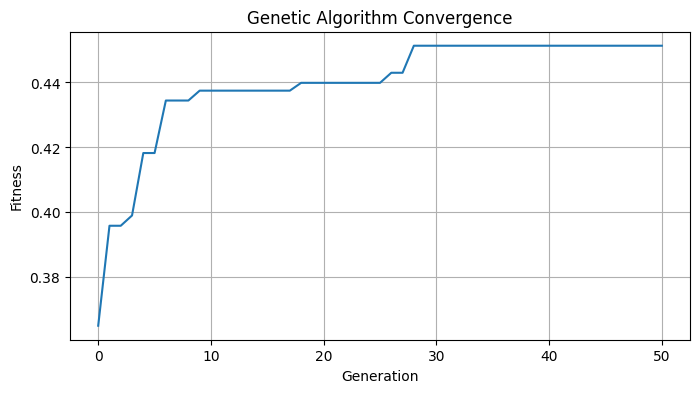

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(ga_instance.best_solutions_fitness)
plt.title("Genetic Algorithm Convergence")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.grid()
plt.show()